In [1]:
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

In [2]:
!pip install opencv-python mediapipe scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

2026-07-01 04:20:31.077883: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782879631.275275      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782879631.329375      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782879631.780622      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782879631.780661      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782879631.780665      58 computation_placer.cc:177] computation placer alr

In [4]:
def printimg(img,rev=True):
    if rev:
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [5]:
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.3,
    running_mode=vision.RunningMode.IMAGE
)
detector = vision.HandLandmarker.create_from_options(options)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1782879646.885103     153 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782879646.908511     153 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [6]:
DATA_DIR = "/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
x_file_path = '/kaggle/working/X_data.npy'
y_file_path = '/kaggle/working/y_labels.npy'

In [7]:
import os

# Define the file paths
x_file_path = '/kaggle/working/X_data.npy'
y_file_path = '/kaggle/working/y_labels.npy'

# Delete X_data.npy if it exists
if os.path.exists(x_file_path):
    os.remove(x_file_path)
    print(f"Deleted: {x_file_path}")
else:
    print(f"File not found (already deleted): {x_file_path}")

# Delete y_labels.npy if it exists
if os.path.exists(y_file_path):
    os.remove(y_file_path)
    print(f"Deleted: {y_file_path}")
else:
    print(f"File not found (already deleted): {y_file_path}")

File not found (already deleted): /kaggle/working/X_data.npy
File not found (already deleted): /kaggle/working/y_labels.npy


In [15]:
def data_preparation():
    if os.path.exists(x_file_path) and os.path.exists(y_file_path):
        X_data = np.load(x_file_path)
        y_labels = np.load(y_file_path)
    else:
        X_data = []
        y_labels  = []
        for dir_ in sorted(os.listdir(DATA_DIR)):
            dir_path = os.path.join(DATA_DIR, dir_)
            for img_path in os.listdir(dir_path):
                img = cv2.imread(os.path.join(dir_path, img_path))
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
                
                detection_result = detector.detect(mp_image)
                
                if detection_result.hand_landmarks:
                    hand_landmarks = detection_result.hand_landmarks[0]
                    
                    row = []
                    for lm in hand_landmarks:
                        row.extend([lm.x, lm.y, lm.z])
                    if len(row) == 63:
                        X_data.append(row)
                        y_labels.append(dir_)
            print(dir_," done")
    
        X_data = np.array(X_data)
        y_labels = np.array(y_labels)
    
    print("Data shape for X Data ANN:", X_data.shape)
    print("Data shape for Y Labels:", y_labels.shape)

    print("DATA SAVED IN THE WORKING DIRECTORY")
    np.save(x_file_path, X_data)
    np.save(y_file_path, y_labels)
    
    return X_data, y_labels

In [13]:
def train_model(X_data,y_labels):
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y_labels)
    num_classes = len(label_encoder.classes_)
    
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_encoded, test_size=0.2, random_state=42)
    
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(63,)), # Accepts the 63 landmark inputs 
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(96, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(num_classes, activation='softmax') # Outputs probability distribution
    ])

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',      
        patience=30,              
        restore_best_weights=True
    )


    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    
    history = model.fit(X_train, y_train, epochs=250, batch_size=32, validation_data=(X_test, y_test),callbacks=[early_stopping])
    return history, model, label_encoder

In [10]:
def show_graph(history):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='royalblue')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='darkorange')
    ax1.set_title('Model Accuracy Over Epochs', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2, color='royalblue')
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='darkorange')
    ax2.set_title('Model Loss Over Epochs', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

--------------------------------------------------
PREPARING DATA: 
Data shape for X Data ANN: (66112, 63)
Data shape for Y Labels: (66112,)
DATA SAVED IN THE WORKING DIRECTORY
--------------------------------------------------
TRAINING THE MODEL: 
Epoch 1/200
1653/1653 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8326 - loss: 0.6001 - val_accuracy: 0.7976 - val_loss: 0.5748
Epoch 2/200
1653/1653 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9121 - loss: 0.2868 - val_accuracy: 0.8642 - val_loss: 0.4163
Epoch 3/200
1653/1653 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9235 - loss: 0.2471 - val_accuracy: 0.9092 - val_loss: 0.2797
Epoch 4/200
1653/1653 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9283 - loss: 0.2305 - val_accuracy: 0.9539 - val_loss: 0.1469
Epoch 5/200
1653/1653 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9308 - loss: 0.2206 - val_accuracy: 0.9626 - val_loss: 0.1291
Epoch 6/200
1653/1653 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9334 - loss: 0.2098 - val_a

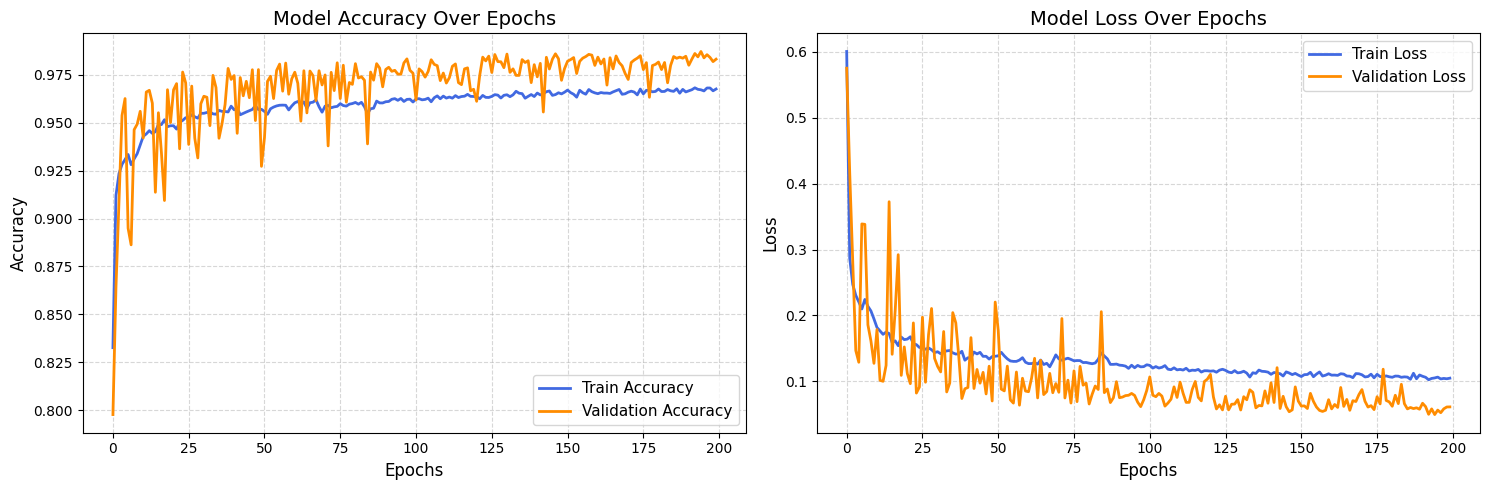

--------------------------------------------------


In [16]:
print("-"*50)
print("PREPARING DATA: ")
X_data, y_labels = data_preparation()
print("-"*50)
print("TRAINING THE MODEL: ")
history,model,label_encoder = train_model(X_data,y_labels)
print("-"*50)
print("DRAWING GRAPHS: ")
show_graph(history)
print("-"*50)

In [17]:
# 2. Extract the last index (the epoch where early stopping kicked in)
# Because restore_best_weights=True, index -1 points exactly to the best epoch's metrics!
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

# 3. Print them cleanly
print("-" * 40)
print(f"Final Training Accuracy:   {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")
print("-" * 40)

----------------------------------------
Final Training Accuracy:   96.76%
Final Validation Accuracy: 98.32%
Final Training Loss:       0.1050
Final Validation Loss:     0.0614
----------------------------------------


In [18]:

def predict_gesture(image_path, model, label_encoder):
    """
    Takes an image path, extracts landmarks using modern MediaPipe, 
    and predicts the sign language gesture using your trained ANN.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return None
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

    detection_result = detector.detect(mp_image)
    
    # 4. If a hand is found, run it through the ANN
    if detection_result.hand_landmarks:
        hand_landmarks = detection_result.hand_landmarks[0]
        
        row = []
        for lm in hand_landmarks:
            row.extend([lm.x, lm.y, lm.z])
            
        if len(row) == 63:
            # Convert to a NumPy array and reshape to (1, 63) because the ANN expects a batch dimension
            input_data = np.array([row])
            
            # 5. Make the prediction
            predictions = model.predict(input_data, verbose=0)
            
            # Find the index with the highest probability
            predicted_class_idx = np.argmax(predictions)
            confidence = predictions[0][predicted_class_idx]
            
            # Decode the integer index back into the original folder label (e.g., 'A', 'B')
            predicted_label = label_encoder.inverse_transform([predicted_class_idx])[0]
            
            return predicted_label, confidence
    return None, 0.0


In [20]:
correct = 0
total = 0
totalconf = 0
for dir_ in sorted(os.listdir(DATA_DIR)):
            dir_path = os.path.join(DATA_DIR, dir_)
            for img_path in os.listdir(dir_path)[:115]:
                full_img_path = os.path.join(dir_path, img_path)
                label, conf = predict_gesture(full_img_path, model, label_encoder)
                if(label==dir_):
                    correct += 1
                totalconf += conf
                total += 1
print("Average Confidence :",totalconf/total)
print("Accuracy :",correct/total)

Average Confidence : 0.76016957
Accuracy : 0.758920539730135
